## **1. Imports & Dataset**

In [2]:
import re
from typing import Literal
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import itables
from itables import show

itables.init_notebook_mode(all_interactive=True)    # full output display with pagination
# itables.options.maxBytes = 0  # IMPORTANT: only disable truncation for testing

In [3]:
df = pd.read_csv('../data/interim/full.csv').drop(columns='Unnamed: 0')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28991 entries, 0 to 28990
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   property_type          28991 non-null  object 
 1   price                  26454 non-null  float64
 2   area                   28989 non-null  float64
 3   area_unit              28989 non-null  object 
 4   n_bedrooms             17209 non-null  float64
 5   n_bathrooms            16374 non-null  float64
 6   n_floors               3352 non-null   float64
 7   address                28988 non-null  object 
 8   city_province          28991 non-null  object 
 9   district               28991 non-null  object 
 10  legal_docs             26031 non-null  object 
 11  facing_direction       12603 non-null  object 
 12  front_width            16648 non-null  float64
 13  raw_price              28989 non-null  object 
 14  raw_area               28989 non-null  object 
 15  ra

C:\Users\asus\AppData\Local\Temp\ipykernel_26984\1309425968.py:1: DtypeWarning: Columns (31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/interim/full.csv').drop(columns='Unnamed: 0')


---
## **2. Missing values**
**needs investigating** = check distribution for price range (use price categories), property_type, area, city_province, legal_docs  

|Column|True missing ratio|Total missing ratio|Meaning of missing values|How to process|
|-|-|-|-|-|
|`property_type`    |0/12k       |0/12k       ||
|`price`            |2/12k       |700/12k     |"Negotiable" prices|Treat as separate price category; drop when modelling|
|`area`             |2/12k       |2/12k       |**Needs investigating**|Drop (only 2 records)|
|`n_bedrooms`       |2k2/12k     |2k2/12k     |**Needs investigating**|Imputation (2k2 missing/12k total)|
|`n_bathrooms`      |2k8/12k     |2k8/12k     |**Needs investigating**|Imputation (2k8 missing/12k total) how to impute|
|`n_floors`         |9k6/12k     |            |Non-existent field `n_floors` in batdongsan.com.vn|Use title/description to extract number of floors|
|`city_province`    |0/12k       |            ||
|`district`         |0/12k       |            ||
|`legal_docs`       |0/12k       |            |**Needs investigating**|Treat a separate category `Khác/Không rõ` (see Feature Standardization - Legal docs)|
|`facing_direction` |7191/12k    |            |**Needs investigating**||
|`front_width`      |4899/12k    |            |**Needs investigating**|Use imputation since non-null counts > 50%|
|`front_road_width` |8438/12k    |            |**Needs investigating**|Use another proxy - road type from geospatial analysis - instead|
|`balcony_direction`|9492/12k    |            |1. Not provided;  2.A house only has 1 floor and doesn't have a balcony|Extract `n_floors` from description/title to decide|

### &emsp; **2.1. Check if null values are not processing errors**  
> Use raw fields to make sure extraction functions didn't produce side effects

#### &emsp; &emsp; `price`: ✅ NaN = Thỏa thuận; 2 are "Not provided"

In [49]:
print(df.loc[df.price.isna(), ['price', 'raw_price']].nunique())
df.loc[df.price.isna(), ['price', 'raw_price', 'scraper']]

price        0
raw_price    2
dtype: int64


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


#### &emsp; &emsp; `area`:  ✅ NaN = Not provided (no raw)

In [51]:
print(df.loc[df.area.isna(), ['area', 'raw_area']].nunique())
df.loc[df.area.isna(), ['area', 'raw_area', 'scraper']]

area        0
raw_area    0
dtype: int64


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


#### &emsp; &emsp; `n_bedrooms`: ✅ Non-nulls are most likely correct (according to claims)

In [64]:
print(df.loc[(df.n_bedrooms.isna())&(~df.raw_n_bedrooms.isna()), ['n_bedrooms', 'raw_n_bedrooms', 'scraper']])
print(df.loc[(~df.n_bedrooms.isna())&(df.raw_n_bedrooms.isna()), ['n_bedrooms', 'raw_n_bedrooms', 'scraper']])

Empty DataFrame
Columns: [n_bedrooms, raw_n_bedrooms, scraper]
Index: []
Empty DataFrame
Columns: [n_bedrooms, raw_n_bedrooms, scraper]
Index: []


#### &emsp; &emsp; `n_bathrooms`: ✅ NaN = Not provided (no raw)

In [67]:
print(df.loc[(df.n_bathrooms.isna())&(~df.raw_n_bathrooms.isna()), ['n_bathrooms', 'raw_n_bathrooms', 'scraper']])
print(df.loc[(~df.n_bathrooms.isna())&(df.raw_n_bathrooms.isna()), ['n_bathrooms', 'raw_n_bathrooms', 'scraper']])

Empty DataFrame
Columns: [n_bathrooms, raw_n_bathrooms, scraper]
Index: []
Empty DataFrame
Columns: [n_bathrooms, raw_n_bathrooms, scraper]
Index: []


#### &emsp; &emsp; `front_width`: ✅ NaN = Not provided (no raw)

In [76]:
print(df.loc[(df.front_width.isna())&(~df.raw_front_width.isna()), ['front_width', 'raw_front_width', 'scraper']])
print(df.loc[(~df.front_width.isna())&(df.raw_front_width.isna()&(df.scraper!="Thiên")), ['front_width', 'raw_front_width', 'scraper']])

Empty DataFrame
Columns: [front_width, raw_front_width, scraper]
Index: []
Empty DataFrame
Columns: [front_width, raw_front_width, scraper]
Index: []


#### &emsp; &emsp; `front_road_width`: ✅ NaN = Not provided (no raw)

In [78]:
print(df.loc[(df.front_road_width.isna())&(~df.raw_front_road_width.isna()), ['front_road_width', 'raw_front_road_width', 'scraper']])
print(df.loc[(~df.front_road_width.isna())&(df.raw_front_road_width.isna()), ['front_road_width', 'raw_front_road_width', 'scraper']])

Empty DataFrame
Columns: [front_road_width, raw_front_road_width, scraper]
Index: []
Empty DataFrame
Columns: [front_road_width, raw_front_road_width, scraper]
Index: []


### &emsp; **2.2. Recover missing data using other fields**

### &emsp; **2.3. Understand true missing patterns**
- Determine the type of missingness:
    - MCAR (Missing Completely at Random)
    - MAR (Missing at Random)
    - MNAR (Missing Not at Random)
- How: Use visualizations (e.g., heatmaps, missingness matrices) and domain knowledge to assess patterns.


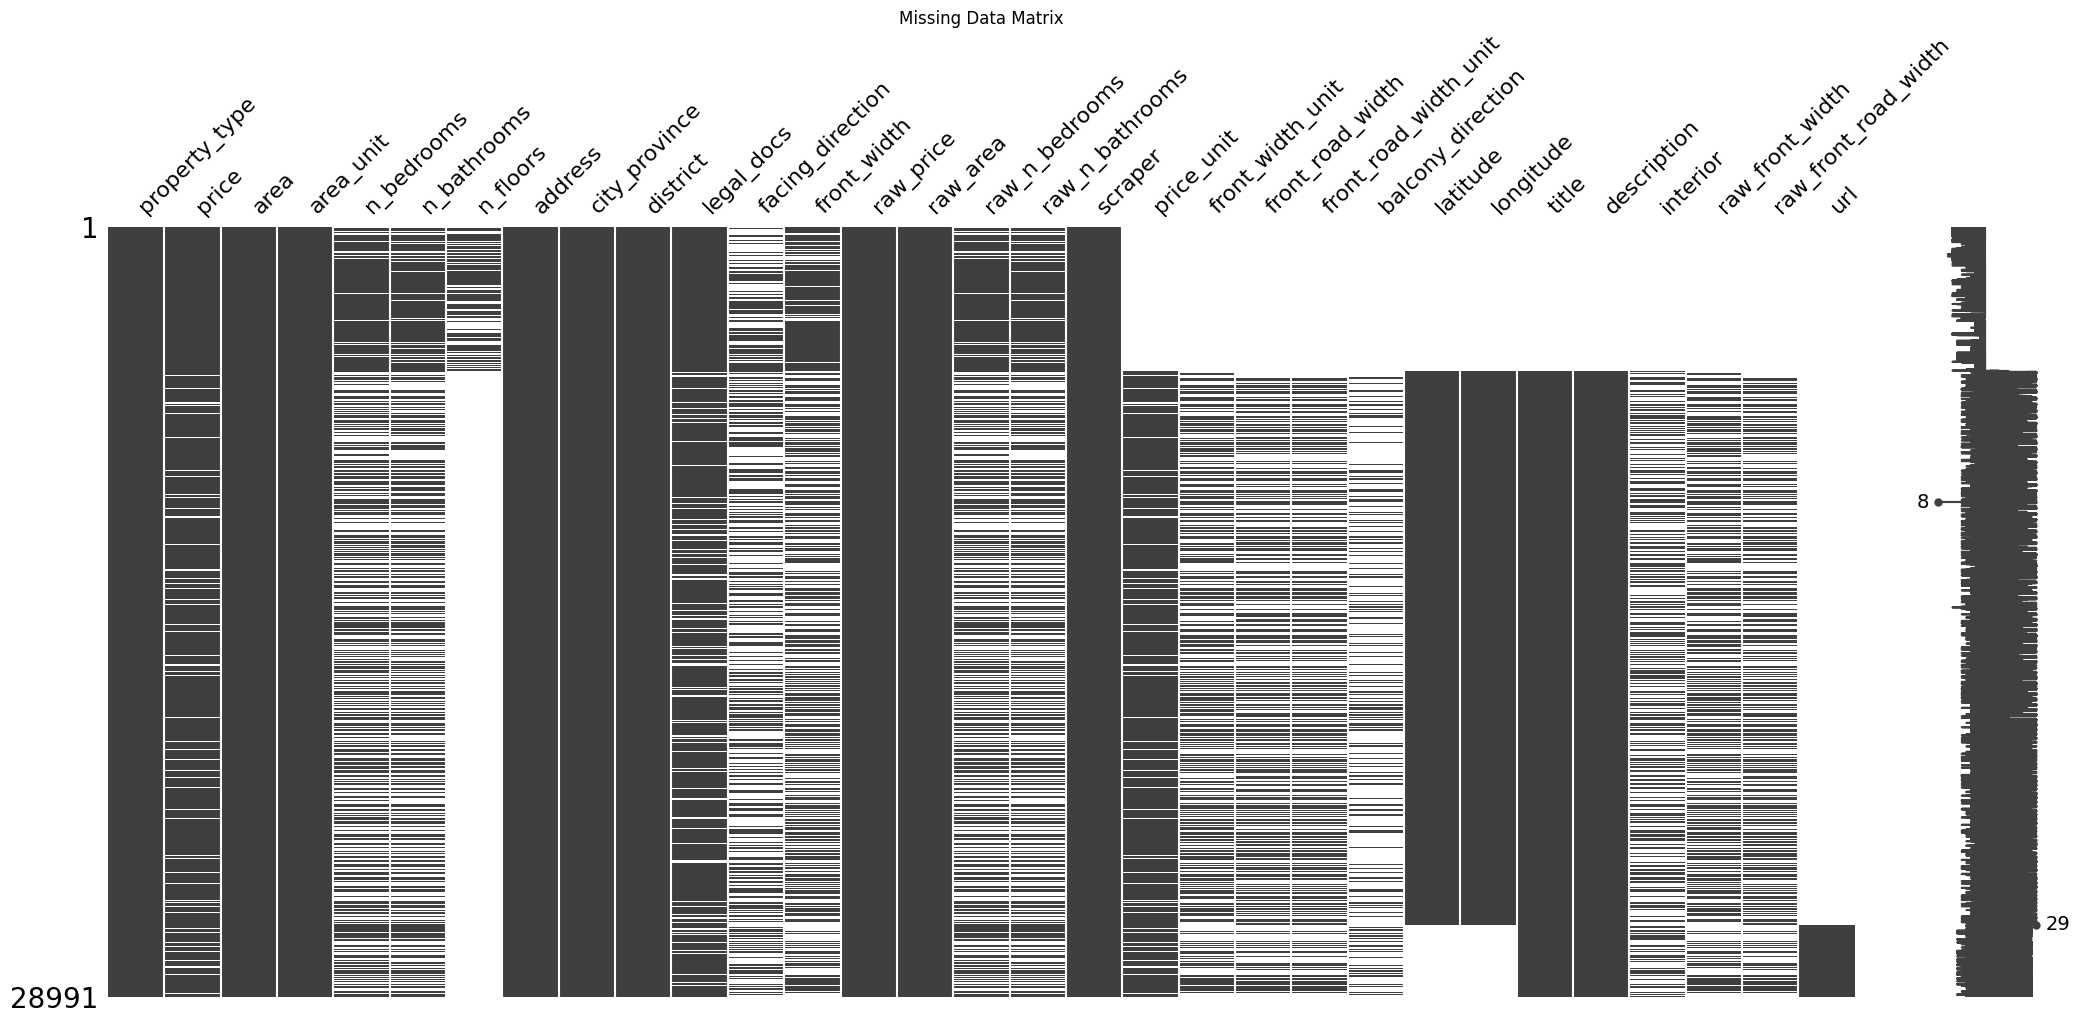

In [4]:
msno.matrix(df)
plt.title("Missing Data Matrix")
plt.show()

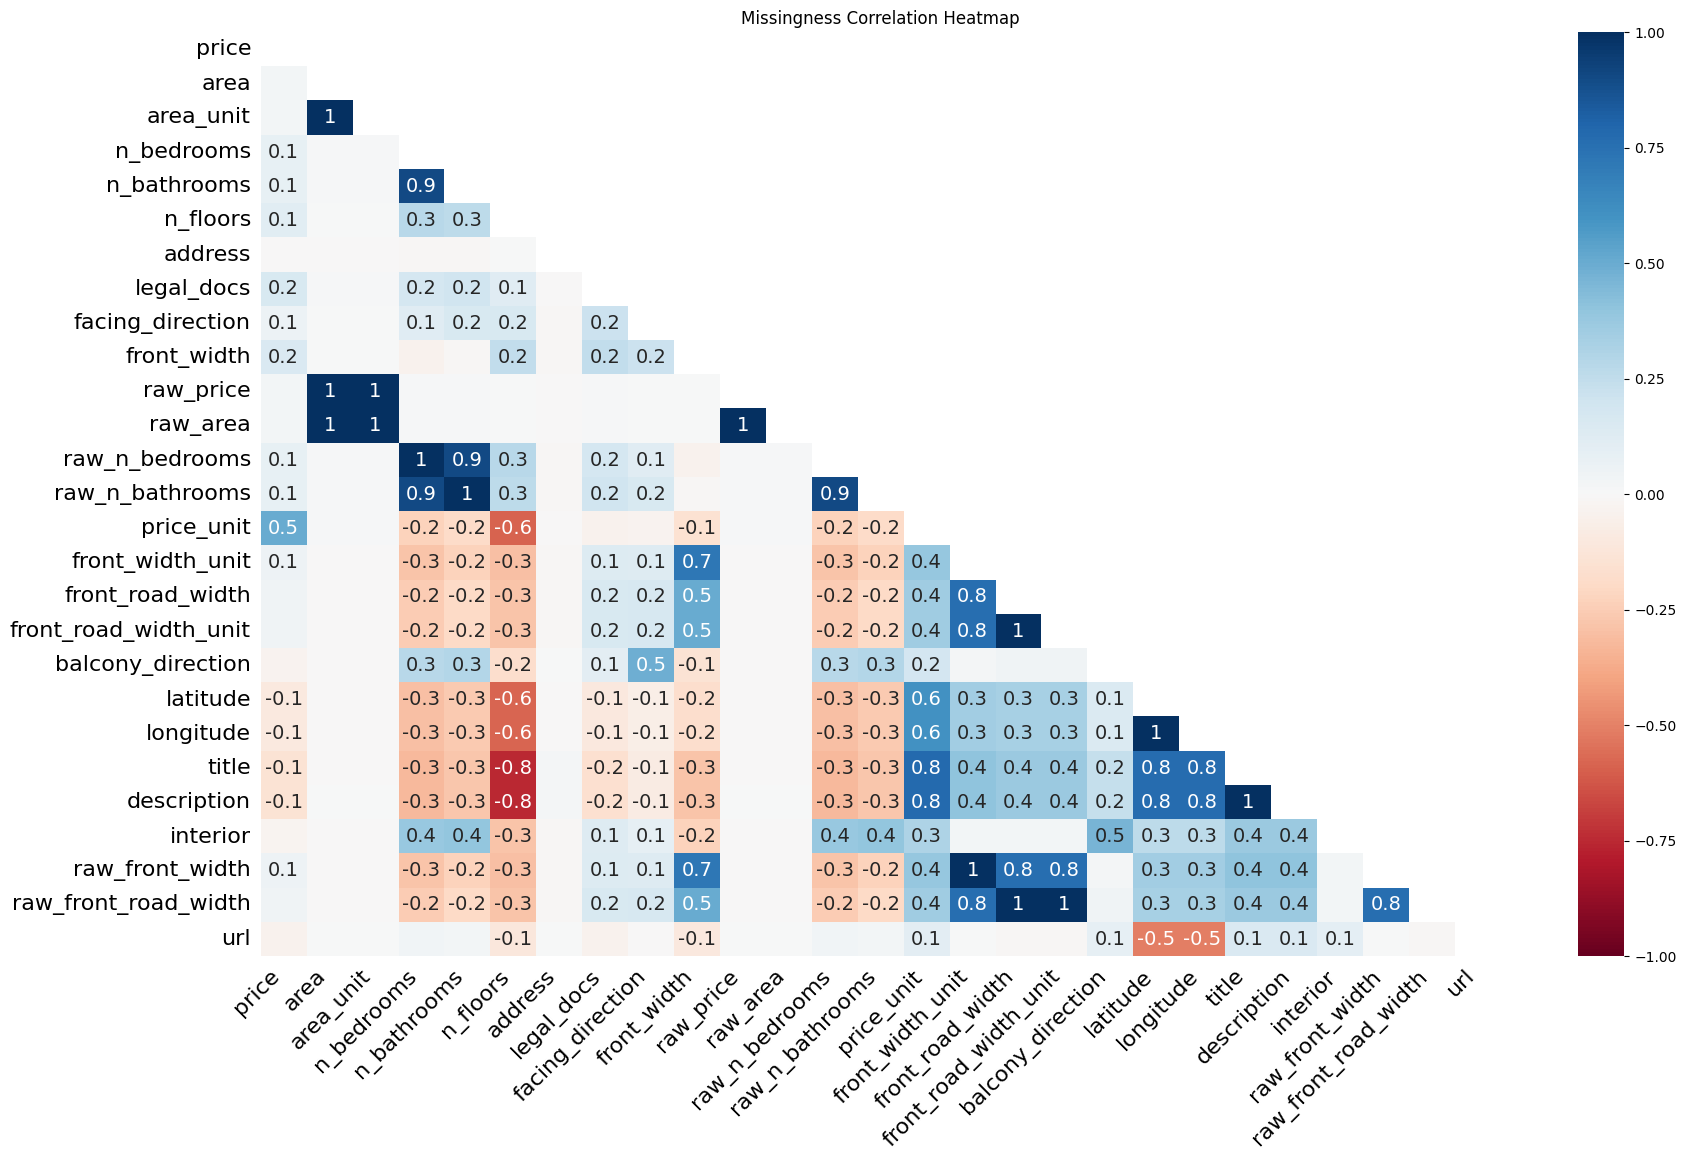

In [5]:
msno.heatmap(df)
plt.title("Missingness Correlation Heatmap")
plt.show()

### &emsp; **2.4. Strategies for truly missing values** (*For modelling & comprehensive analysis*)
- For MCAR:  
    ...
- For MAR:  
    ...
- For MNAR:  
    ...


- Drop rows/columns (if missingness is high and data is non-critical).
- Impute if missing < 50% total:
    - Mean/median/mode (for numerical or categorical data).
    - Forward/backward fill (for time series).
    - Predictive models (e.g., KNN, regression).
    - Domain-specific rules

---
## **3. Data correctness assessment**
> **Strategy: 1 overall round, multiple follow-up rounds**  
>1. Randomly select 200 samples to manually check for correctness/plausibility  
>    -> 95% CI for correctness proportion, patterns of incorrect values  
>2. Follow-up: If there's a pattern for incorrect values, filter them, then try to recover correct value 

#### &emsp; &emsp; `price`: ✅ Non-nulls are most likely correct

In [ ]:
print(df.loc[~df.price.isna(), ['price', 'price_unit','raw_price', 'scraper']].nunique())
df.loc[(~df.price.isna()) & (df.scraper != "Thiên"), ['price', 'price_unit','raw_price', 'scraper']]

#### &emsp; &emsp; `area`:  ⚠️ Non-nulls have problems: mixed use of . for thousands and fractional separator, dimension multiplying issues (Thiên's dataset)

In [ ]:
print(df.loc[~df.area.isna(), ['area', 'area_unit','raw_area', 'scraper']].nunique())
df.loc[(~df.area.isna())&(df.scraper == "Nhân"), ['area', 'area_unit','raw_area', 'scraper']]

area         3034
area_unit       1
raw_area     4704
scraper         3
dtype: int64


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


#### &emsp; &emsp; `n_bedrooms`: ✅ Non-nulls are most likely correct

In [ ]:
df.loc[(~df.n_bedrooms.isna())&(~df.raw_n_bedrooms.isna()&(df.scraper=="Quang")), ['n_bedrooms', 'raw_n_bedrooms', 'scraper']]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


#### &emsp; &emsp; `n_bathrooms`: ✅ Non-nulls are most likely correct

In [ ]:
# check extracted features
df.loc[(~df.n_bathrooms.isna())&(~df.raw_n_bathrooms.isna()&(df.scraper == "Quang")), ['n_bathrooms', 'raw_n_bathrooms', 'scraper']]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


#### &emsp; &emsp; `front_width`: ✅ 

In [ ]:
df.loc[(~df.front_width.isna())&(~df.raw_front_width.isna()), ['front_width', 'raw_front_width', 'scraper']]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


#### &emsp; &emsp; `front_road_width`: ❌ Non-nulls are super sus:  
Checks for large values (>20m) using Google satellite images show they're often smaller than what are claimed, esp. for projects

In [ ]:
df.loc[(~df.front_road_width.isna())&(~df.raw_front_road_width.isna()), ['front_road_width', 'raw_front_road_width', 'scraper', 'address']]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


---
## **4. Feature standardization**
- Non-null `area`, `front_width`, `front_road_width` values are already unified   

To-dos:
- `price` to billion VND
- `property_type` to {"Nhà mặt tiền", "Nhà hẻm", "Biệt thự", "Chung cư", "Nhà riêng"}
  - Remove records that don't fall in these categories
- `legal_docs` to {"Sổ đỏ/hồng riêng", "Hợp đồng mua bán", "Sổ chung", "Đang chờ sổ", "Văn bản thỏa thuận", "Khác/Không rõ"}
- Unify names for `city_province`
- Unify names for `district`

In [5]:
df.describe(include="all")

,property_type,price,area,area_unit,n_bedrooms,n_bathrooms,n_floors,address,city_province,district,legal_docs,facing_direction,front_width,price_unit,front_width_unit,front_road_width,front_road_width_unit,balcony_direction,interior
count,21975,20049.000000,2.197300e+04,21973,12743.000000,12149.000000,2476.000000,21972,21975,21975,19726,9334,12317.000000,16466,9342,8608.000000,8608,4428,8525
unique,18,NaN,NaN,1,NaN,NaN,NaN,10930,65,559,268,12,NaN,6,1,NaN,1,8,518
top,Căn hộ chung cư,NaN,NaN,m²,NaN,NaN,NaN,"Dự án Aria Bay Tower, Phường Hùng Thắng, Hạ Lo...",Hồ Chí Minh,Hạ Long,Sổ đỏ/ Sổ hồng,Đông - Nam,NaN,tỷ,m,NaN,m,Đông - Nam,Đầy đủ
freq,2296,NaN,NaN,21973,NaN,NaN,NaN,231,5335,1073,10828,1981,NaN,14407,9342,NaN,8608,1395,3728
mean,NaN,38.979134,1.087656e+04,NaN,3.900573,3.595852,2.603796,NaN,NaN,NaN,NaN,NaN,31.158750,NaN,NaN,14.790750,NaN,NaN,NaN
std,NaN,241.258184,1.057718e+06,NaN,6.597951,6.153505,2.112046,NaN,NaN,NaN,NaN,NaN,1814.641899,NaN,NaN,14.592185,NaN,NaN,NaN
min,NaN,0.100000,1.050000e+00,NaN,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,NaN,NaN
25%,NaN,3.500000,6.000000e+01,NaN,2.000000,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,4.900000,NaN,NaN,6.000000,NaN,NaN,NaN
50%,NaN,7.800000,9.400000e+01,NaN,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,5.500000,NaN,NaN,12.000000,NaN,NaN,NaN
75%,NaN,22.800000,1.700000e+02,NaN,4.000000,4.000000,3.000000,NaN,NaN,NaN,NaN,NaN,9.590000,NaN,NaN,19.500000,NaN,NaN,NaN


### &emsp; **4.1. Price**

In [6]:
df["price_unit"].unique()

array([nan, 'tỷ', 'triệu', 'triệu/m²', 'nghìn/m²', 'tỷ/m²', 'nghìn'],
      dtype=object)

In [7]:
CONVERSION_MAP = {
    "tỷ": 1,
    "tỷ/m²": 1,
    "triệu": 1e-3,
    "triệu/m²": 1e-3,
    "nghìn/m²": 1e-6, 
    "nghìn": 1e-6   
}
def price_to_bil(row, val_col_label:str, unit_col_label:str):
    value = row[val_col_label]
    if not value:
        return None
    
    unit = row[unit_col_label]
    conversion_factor = CONVERSION_MAP.get(unit)
    if unit and conversion_factor:
        return value * conversion_factor
    else:        # from muaban_net.csv dataset
        return value

In [8]:
# convert all to million
df["price"] = df.apply(price_to_bil, axis=1, args=("price","price_unit"))

# convert price per m2 units to full price
price_per_area = df.price_unit.isin(["tỷ/m²", "triệu/m²", "nghìn/m²"])
df.loc[price_per_area, "price"] = df.loc[price_per_area, "price"] * df.loc[price_per_area, "area"]

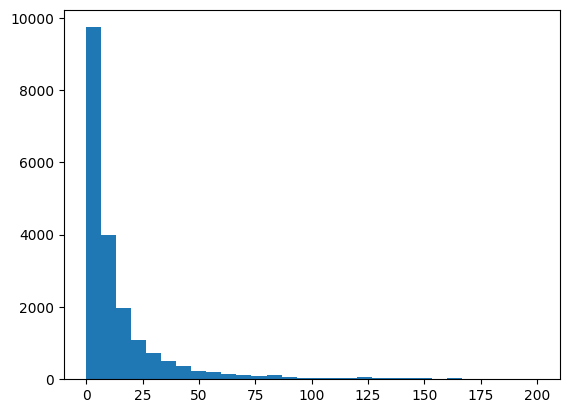

In [9]:
plt.hist(df.price, bins=30, range=(0,200))
plt.show()

### &emsp; **4.2. Property type**

In [10]:
df.property_type.unique()

array(['Nhà mặt tiền', 'Nhà hẻm ngõ', 'Biệt thự', 'Biệt thự, Villa',
       'Nhà hẻm, ngõ', 'Mặt tiền', 'Căn hộ chung cư',
       'Căn hộ chung cư mini', 'Nhà riêng', 'Nhà biệt thự, liền kề',
       'Nhà mặt phố', 'Shophouse, nhà phố thương mại', 'Đất nền dự án',
       'Đất', 'Condotel', 'Trang trại, khu nghỉ dưỡng', 'Kho, nhà xưởng',
       'Khác'], dtype=object)

In [7]:
df.loc[df.property_type.isin(['Nhà mặt tiền', 'Mặt tiền', 'Nhà mặt phố']), 'property_type'] = 'Nhà mặt tiền'
df.loc[df.property_type.isin(['Nhà hẻm ngõ', 'Nhà hẻm, ngõ']), 'property_type'] = 'Nhà hẻm ngõ'
df.loc[df.property_type.isin(['Biệt thự', 'Biệt thự, Villa', 'Nhà biệt thự, liền kề']), 'property_type'] = 'Biệt thự'
df.loc[df.property_type.isin(['Căn hộ chung cư', 'Căn hộ chung cư mini']), 'property_type'] = 'Căn hộ chung cư'

df = df.loc[df.property_type.isin(['Nhà mặt tiền', 'Nhà hẻm ngõ', 'Nhà riêng', 'Biệt thự', 'Căn hộ chung cư'])]

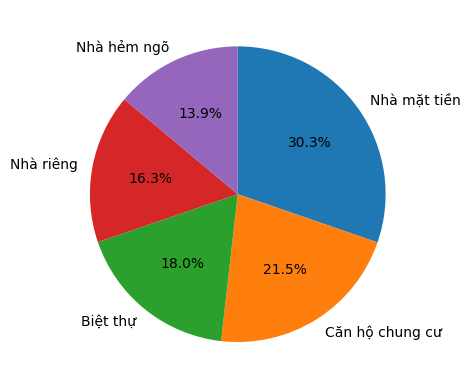

In [12]:
plt.pie(
    df.groupby('property_type').size().sort_values(ascending=False), 
    labels=df.groupby('property_type').size().sort_values(ascending=False).index, 
    startangle=90, 
    counterclock=False, 
    autopct='%1.1f%%'
)
plt.show()

### &emsp; **4.3. Legal docs**

In [13]:
legals = df.legal_docs.unique()
legals

array(['Sổ hồng', 'Sổ đỏ', 'Giấy tờ hợp lệ', 'Giấy tờ khác',
       'Hợp đồng mua bán', 'Đang chờ sổ', 'Sổ hồng đầy đủ', 'HDMB',
       'Sổ đỏ/ Sổ hồng', 'Hợp đồng mua bán.', 'Sổ đỏ/ Sổ hồng.', 'HĐMB',
       nan, 'Sổ hồng riêng', 'Có sổ.', 'Sổ hồng đã hoàn công năm 2025',
       'Sổ hồng (sử dụng chung).',
       'Bùi Xương Trạch, khương đình, Thanh Xuân.',
       'Đã có sổ đỏ - mua bán vi bằng',
       'Sổ đỏ chính chủ, sẵn sàng giao dịch.', 'Sổ hồng.', 'Có sổ',
       'Có sổ( sử dụng chung).', 'Sổ hồng vĩnh viễn.',
       'Sổ đỏ/ Sổ hồng', 'Sổ đỏ.', 'Mua bán công chứng vi bằng',
       'Nhà đã có sổ đỏ.', 'Có sổ đỏ.', 'sổ đỏ sang tên',
       'Sổ đỏ chính chủ', 'Hợp đồng mua bán vi bằng',
       'Sổ đỏ/ Sổ hồng chung', 'Sổ đỏ sang tên.', 'Sổ đỏ sang tên',
       'Pháp lý: Giao dịch vi bằng, thủ tục nhanh gọn.', 'HĐ vi bằng',
       'Mỗi căn hộ có 1 bìa hồng. Mua bán lập HĐ vi bằng.', 'Đã có sổ',
       'Sổ đỏ/ Sổ hồng ( sử dụng chung)', 'Sổ hồng riêng.', 'Sổ hồng sdc',
       'S

In [14]:
def standardize_legal_doc_types(s: str) -> None|Literal['Sổ đỏ/hồng riêng', 'Hợp đồng mua bán', 'Sổ dùng chung', 'Văn bản thỏa thuận', 'Đang chờ sổ', 'Giấy tờ khác']:
    if not s or not isinstance(s, str) or not s.strip():
        return 'Khác/Không rõ'
    
    s = s.lower().strip()
    s = re.sub(r'[:,.-/()+]', '', s)

    if re.search(r'chờ sổ|chờ cấp sổ', s):
        return 'Đang chờ sổ'
    # 2 cái 'sổ' nhìn giống nhau nhưng khác (1 cái đầu có 3 kí tự là s, ô, dấu hỏi)
    if re.search(r'sổ|sổ|bìa hồng|sđ|bìa đỏ|có số|pháp\s*l[íý]:?\s*đầy đủ|đầy đủ\s*pháp\s*l[íý]|pháp\s*l[íý]\s*chuẩn|pháp\s*l[íý]\s*rõ\s*ràng|giấy tờ hợp lệ|sang tên',s):
        if re.search(r'sử dụng chung|sổ chung|đồng sở hữu|đồng sh|sdc|chung|đsh',s):
            return 'Sổ đỏ/hồng chung'
        return 'Sổ đỏ/hồng riêng'
    if re.search(r'vi bằng|vb|văn bản thoã thuận|vbtt|thỏa thuận|thoả thuận|đặt cọc|góp vốn',s):
        return 'Văn bản thỏa thuận'
    if re.search(r'hợp đồng mua bán|hđmb|hdmb|hợp đồng|hđ|hd', s):
        return 'Hợp đồng mua bán'
    else:
        return 'Khác/Không rõ'

In [15]:
# test function
transformed = {s:standardize_legal_doc_types(s) for s in legals}
transformed

{'Sổ hồng': 'Sổ đỏ/hồng riêng',
 'Sổ đỏ': 'Sổ đỏ/hồng riêng',
 'Giấy tờ hợp lệ': 'Sổ đỏ/hồng riêng',
 'Giấy tờ khác': 'Khác/Không rõ',
 'Hợp đồng mua bán': 'Hợp đồng mua bán',
 'Đang chờ sổ': 'Đang chờ sổ',
 'Sổ hồng đầy đủ': 'Sổ đỏ/hồng riêng',
 'HDMB': 'Hợp đồng mua bán',
 'Sổ đỏ/ Sổ hồng': 'Sổ đỏ/hồng riêng',
 'Hợp đồng mua bán.': 'Hợp đồng mua bán',
 'Sổ đỏ/ Sổ hồng.': 'Sổ đỏ/hồng riêng',
 'HĐMB': 'Hợp đồng mua bán',
 nan: 'Khác/Không rõ',
 'Sổ hồng riêng': 'Sổ đỏ/hồng riêng',
 'Có sổ.': 'Sổ đỏ/hồng riêng',
 'Sổ hồng đã hoàn công năm 2025': 'Sổ đỏ/hồng riêng',
 'Sổ hồng (sử dụng chung).': 'Sổ đỏ/hồng chung',
 'Bùi Xương Trạch, khương đình, Thanh Xuân.': 'Khác/Không rõ',
 'Đã có sổ đỏ - mua bán vi bằng': 'Sổ đỏ/hồng riêng',
 'Sổ đỏ chính chủ, sẵn sàng giao dịch.': 'Sổ đỏ/hồng riêng',
 'Sổ hồng.': 'Sổ đỏ/hồng riêng',
 'Có sổ': 'Sổ đỏ/hồng riêng',
 'Có sổ( sử dụng chung).': 'Sổ đỏ/hồng chung',
 'Sổ hồng vĩnh viễn.': 'Sổ đỏ/hồng riêng',
 'Sổ đỏ/ Sổ hồng': 'Sổ đỏ/hồng riêng',
 'Sổ đ

In [16]:
df.loc[:,'legal_docs'] = df.legal_docs.apply(standardize_legal_doc_types)

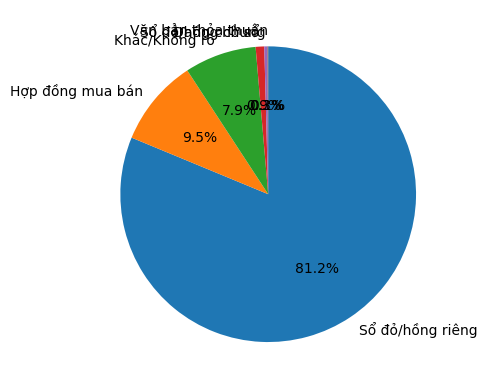

In [17]:
plt.pie(
    df.groupby('legal_docs').size().sort_values(ascending=False), 
    labels=df.groupby('legal_docs').size().sort_values(ascending=False).index, 
    startangle=90, 
    counterclock=False, 
    autopct='%1.1f%%'
)
plt.show()

### &emsp;**4.4. City/Province**

In [18]:
df.city_province.unique()

array(['TP.HCM', 'Hà Nội', 'Đà Nẵng', 'Hải Phòng', 'Cần Thơ', 'Đồng Nai',
       'Bình Dương', 'Long An', 'Lâm Đồng', 'Bà Rịa - Vũng Tàu',
       'Đắk Lắk', 'Tiền Giang', 'Bắc Ninh', 'Quảng Nam', 'Khánh Hòa',
       'Nghệ An', 'An Giang', 'Bạc Liêu', 'Bắc Giang', 'Bến Tre',
       'Bình Định', 'Bình Phước', 'Bình Thuận', 'Cà Mau', 'Đồng Tháp',
       'Gia Lai', 'Hậu Giang', 'Hưng Yên', 'Kiên Giang', 'Kon Tum',
       'Lào Cai', 'Nam Định', 'Ninh Thuận', 'Phú Thọ', 'Phú Yên',
       'Quảng Bình', 'Quảng Ngãi', 'Quảng Ninh', 'Sóc Trăng', 'Tây Ninh',
       'Thái Bình', 'Thái Nguyên', 'Thanh Hóa', 'Thừa Thiên Huế',
       'Trà Vinh', 'Vĩnh Long', 'Vĩnh Phúc', 'Yên Bái', 'Hồ Chí Minh',
       'Hòa Bình', 'Bà Rịa Vũng Tàu', 'Hải Dương', 'Hà Nam', 'Đắk Nông',
       'Ninh Bình', 'Sơn La', 'Thành phố Hà Nội', 'Thành phố Hồ Chí Minh'],
      dtype=object)

In [19]:
df.loc[df.city_province.isin(['Thành phố Hồ Chí Minh', 'thành phố Hồ Chí Minh', 'Hồ Chí Minh', 'TPHCM']), 'city_province'] = 'TP.HCM'
df.loc[df.city_province == 'Thành phố Hà Nội', 'city_province'] = 'Hà Nội'
df.loc[df.city_province == 'Bà Rịa - Vũng Tàu', 'city_province'] = 'Bà Rịa Vũng Tàu'

In [20]:
df.city_province.unique()

array(['TP.HCM', 'Hà Nội', 'Đà Nẵng', 'Hải Phòng', 'Cần Thơ', 'Đồng Nai',
       'Bình Dương', 'Long An', 'Lâm Đồng', 'Bà Rịa Vũng Tàu', 'Đắk Lắk',
       'Tiền Giang', 'Bắc Ninh', 'Quảng Nam', 'Khánh Hòa', 'Nghệ An',
       'An Giang', 'Bạc Liêu', 'Bắc Giang', 'Bến Tre', 'Bình Định',
       'Bình Phước', 'Bình Thuận', 'Cà Mau', 'Đồng Tháp', 'Gia Lai',
       'Hậu Giang', 'Hưng Yên', 'Kiên Giang', 'Kon Tum', 'Lào Cai',
       'Nam Định', 'Ninh Thuận', 'Phú Thọ', 'Phú Yên', 'Quảng Bình',
       'Quảng Ngãi', 'Quảng Ninh', 'Sóc Trăng', 'Tây Ninh', 'Thái Bình',
       'Thái Nguyên', 'Thanh Hóa', 'Thừa Thiên Huế', 'Trà Vinh',
       'Vĩnh Long', 'Vĩnh Phúc', 'Yên Bái', 'Hòa Bình', 'Hải Dương',
       'Hà Nam', 'Đắk Nông', 'Ninh Bình', 'Sơn La'], dtype=object)

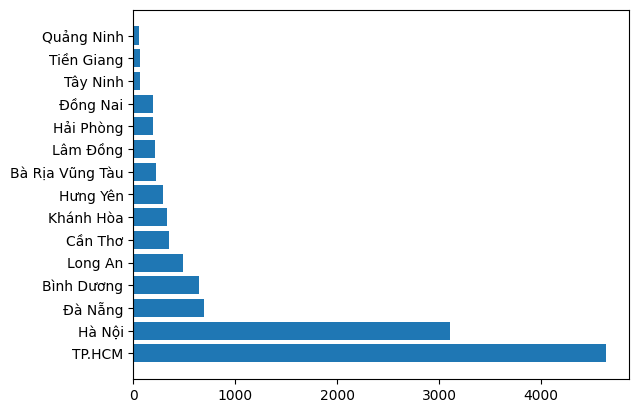

In [21]:
n=15
plt.barh(
    df.groupby('city_province').size().sort_values(ascending=False)[:n].index,
    df.groupby('city_province').size().sort_values(ascending=False)[:n]
)
plt.show()

### &emsp;**4.5. District**

In [22]:
df.loc[df.city_province == "TP.HCM", "district"].unique()

array(['Quận 5', 'Quận 7', 'Quận 6', 'Huyện Bình Chánh', 'Quận 10',
       'Quận 3', 'Quận Gò Vấp', 'Quận 1', 'Quận 12', 'Quận Tân Bình',
       'Quận Tân Phú', 'Quận Bình Thạnh', 'Quận Bình Tân', 'Quận 11',
       'Quận Phú Nhuận', 'Huyện Nhà Bè', 'Quận 8', 'TP. Thủ Đức - Quận 2',
       'Huyện Hóc Môn', 'TP. Thủ Đức - Quận Thủ Đức',
       'TP. Thủ Đức - Quận 9', 'Huyện Cần Giờ', 'Quận 4', 'Huyện Củ Chi',
       'Quận 2', 'Quận 9', 'Nhà Bè', 'Tân Bình', 'Bình Thạnh', 'Bình Tân',
       'Gò Vấp', 'Bình Chánh', 'Tân Phú', 'Thủ Đức', 'Phú Nhuận',
       'Cần Giờ', 'Hóc Môn', 'Củ Chi', 'Phường Chánh Phú Hòa',
       'Phường An Khánh'], dtype=object)

In [23]:
def standardize_district(s:str)->str:
    s = s.strip().lower()
    s = re.sub(r'\s*-\s*', ' - ', s)   # For Phan Rang - Tháp Chàm

    if 'thủ đức' in s or 'quận 2' in s or 'quận 9' in s:
        return 'Thủ Đức'
    if re.search(r'quận \d+',s):
        return re.search(r'quận \d+', s).group(0).title()
    return re.sub(r'quận|^huyện|tp.|thành phố|thị xã', '', s).strip().title()

In [24]:
test_std_distr = {s: standardize_district(s) for s in df.district.unique()}
test_std_distr

{'Quận 5': 'Quận 5',
 'Quận 7': 'Quận 7',
 'Quận 6': 'Quận 6',
 'Huyện Bình Chánh': 'Bình Chánh',
 'Quận 10': 'Quận 10',
 'Quận 3': 'Quận 3',
 'Quận Gò Vấp': 'Gò Vấp',
 'Quận 1': 'Quận 1',
 'Quận 12': 'Quận 12',
 'Quận Tân Bình': 'Tân Bình',
 'Quận Tân Phú': 'Tân Phú',
 'Quận Bình Thạnh': 'Bình Thạnh',
 'Quận Bình Tân': 'Bình Tân',
 'Quận 11': 'Quận 11',
 'Quận Phú Nhuận': 'Phú Nhuận',
 'Huyện Nhà Bè': 'Nhà Bè',
 'Quận 8': 'Quận 8',
 'TP. Thủ Đức - Quận 2': 'Thủ Đức',
 'Huyện Hóc Môn': 'Hóc Môn',
 'TP. Thủ Đức - Quận Thủ Đức': 'Thủ Đức',
 'TP. Thủ Đức - Quận 9': 'Thủ Đức',
 'Huyện Cần Giờ': 'Cần Giờ',
 'Quận 4': 'Quận 4',
 'Huyện Củ Chi': 'Củ Chi',
 'Quận Ba Đình': 'Ba Đình',
 'Quận Hoàn Kiếm': 'Hoàn Kiếm',
 'Quận Hoàng Mai': 'Hoàng Mai',
 'Quận Hai Bà Trưng': 'Hai Bà Trưng',
 'Huyện Đông Anh': 'Đông Anh',
 'Quận Long Biên': 'Long Biên',
 'Quận Bắc Từ Liêm': 'Bắc Từ Liêm',
 'Quận Tây Hồ': 'Tây Hồ',
 'Quận Hà Đông': 'Hà Đông',
 'Quận Thanh Xuân': 'Thanh Xuân',
 'Quận Đống Đa': 'Đống Đa'

In [25]:
df.loc[:,'district'] = df.district.apply(standardize_district)

In [26]:
df.loc[df.city_province == "Quảng Ninh", "district"].unique()

array(['Hạ Long', 'Cẩm Phả', 'Vân Đồn'], dtype=object)

## **5. Duplicates**
Use subset of features [`address`, `property_type`, `area`, `price`, `n_bedrooms`, `n_bathrooms`] to filter duplicates

-> Handle both recraped posts + separate post about the same location

In [ ]:
df_no_duplicates = df.drop_duplicates(subset=df.columns.difference(['url', 'title', 'description', 'scraper']))

print(f"Number of rows before removing duplicates: {len(df)}")
print(f"Number of rows after removing duplicates: {len(df_no_duplicates)}")

df = df_no_duplicates

Number of rows before removing duplicates: 23993
Number of rows after removing duplicates: 23958


## **Checkpoint 1: Analysis-ready data**

In [27]:
checkpoint_df = df[['property_type', 'price', 'area', 'n_bedrooms', 'n_bathrooms', 'n_floors', 'city_province', 'district', 'legal_docs', 'facing_direction', 'front_width', 'front_road_width', 'balcony_direction']].reset_index(drop=True)
checkpoint_df

,property_type,price,area,n_bedrooms,n_bathrooms,n_floors,city_province,district,legal_docs,facing_direction,front_width,front_road_width,balcony_direction
0,Nhà mặt tiền,48.00,65.0,NaN,NaN,4.0,TP.HCM,Quận 5,Sổ đỏ/hồng riêng,NaN,4.0,NaN,NaN
1,Nhà hẻm ngõ,8.20,105.0,6.0,6.0,2.0,TP.HCM,Quận 7,Sổ đỏ/hồng riêng,NaN,4.6,NaN,NaN
2,Biệt thự,300.00,1100.0,8.0,10.0,3.0,TP.HCM,Quận 6,Sổ đỏ/hồng riêng,NaN,20.0,NaN,NaN
3,Nhà mặt tiền,0.89,60.0,3.0,3.0,NaN,TP.HCM,Bình Chánh,Sổ đỏ/hồng riêng,NaN,4.0,NaN,NaN
4,Nhà mặt tiền,40.00,140.0,8.0,8.0,3.0,TP.HCM,Quận 10,Sổ đỏ/hồng riêng,NaN,7.5,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12063,Nhà riêng,2.25,43.0,3.0,3.0,NaN,TP.HCM,Bình Thạnh,Khác/Không rõ,NaN,NaN,NaN,NaN
12064,Căn hộ chung cư,11.00,95.6,3.0,2.0,NaN,Hà Nội,Cầu Giấy,Sổ đỏ/hồng riêng,NaN,NaN,NaN,NaN
12065,Nhà mặt tiền,8.50,96.9,4.0,4.0,NaN,Khánh Hòa,Nha Trang,Sổ đỏ/hồng riêng,Đông - Nam,5.0,12.0,Đông - Nam
12066,Biệt thự,10.60,75.0,5.0,5.0,NaN,Hưng Yên,Văn Giang,Hợp đồng mua bán,Đông - Nam,5.0,13.0,Đông - Nam


In [28]:
checkpoint_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12068 entries, 0 to 12067
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   property_type      12068 non-null  object 
 1   price              11381 non-null  float64
 2   area               12066 non-null  float64
 3   n_bedrooms         9835 non-null   float64
 4   n_bathrooms        9216 non-null   float64
 5   n_floors           2476 non-null   float64
 6   city_province      12068 non-null  object 
 7   district           12068 non-null  object 
 8   legal_docs         12068 non-null  object 
 9   facing_direction   4874 non-null   object 
 10  front_width        7169 non-null   float64
 11  front_road_width   3625 non-null   float64
 12  balcony_direction  2571 non-null   object 
dtypes: float64(7), object(6)
memory usage: 1.2+ MB


In [29]:
df.describe(include="all")

,property_type,price,area,area_unit,n_bedrooms,n_bathrooms,n_floors,address,city_province,district,legal_docs,facing_direction,front_width,price_unit,front_width_unit,front_road_width,front_road_width_unit,balcony_direction,interior
count,12068,11381.000000,12066.000000,12066,9835.000000,9216.000000,2476.000000,12065,12068,12068,12068,4874,7169.000000,7798,4194,3625.000000,3625,2571,5323
unique,5,NaN,NaN,1,NaN,NaN,NaN,6337,54,235,6,12,NaN,5,1,NaN,1,8,393
top,Nhà mặt tiền,NaN,NaN,m²,NaN,NaN,NaN,"Xã Mỹ Hạnh Nam, Huyện Đức Hoà, Long An",TP.HCM,Thủ Đức,Sổ đỏ/hồng riêng,Đông - Nam,NaN,tỷ,m,NaN,m,Đông - Nam,Đầy đủ
freq,3655,NaN,NaN,12066,NaN,NaN,NaN,57,4632,1033,9805,797,NaN,7451,4194,NaN,3625,768,2443
mean,NaN,18.775638,142.053916,NaN,4.140722,3.869141,2.603796,NaN,NaN,NaN,NaN,NaN,6.941710,NaN,NaN,13.660091,NaN,NaN,NaN
std,NaN,41.860531,492.775867,NaN,5.793277,5.909943,2.112046,NaN,NaN,NaN,NaN,NaN,7.209883,NaN,NaN,12.214907,NaN,NaN,NaN
min,NaN,0.000003,1.050000,NaN,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,NaN,NaN
25%,NaN,3.900000,58.025000,NaN,2.000000,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,4.200000,NaN,NaN,6.000000,NaN,NaN,NaN
50%,NaN,7.900000,81.000000,NaN,3.000000,3.000000,2.000000,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,12.000000,NaN,NaN,NaN
75%,NaN,18.200000,126.000000,NaN,4.000000,4.000000,3.000000,NaN,NaN,NaN,NaN,NaN,7.500000,NaN,NaN,17.000000,NaN,NaN,NaN


In [ ]:
df.to_csv('../data/processed/analysis_ready.csv')